In [1]:
from model_ranking import (
    load_h5,
    HammingDistanceEval,
    jaccard_index,
    get_mask
)
import matplotlib.pyplot as plt
import numpy as np

/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


INFO: P [MainThread] 2025-10-15 14:27:40,053 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path_unp = "/scratch/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_EPFL_gap/consistency/P_full/E_model_Res1/norm_Normalize/none/predictions/test_predictions.h5"
preds_unp = load_h5(path_unp, "predictions")

In [3]:
path = "/scratch/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_EPFL_gap/consistency/P_full/E_model_Res1/norm_Normalize/gauss_a015-02/predictions/test_predictions.h5"
NHD_scores = load_h5(path, "NHD_consis")
preds_p = load_h5(path, "predictions")

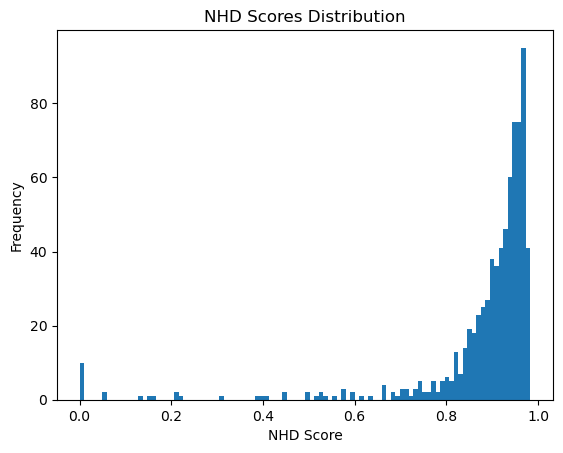

In [4]:
plt.hist(1 - NHD_scores.flatten(), bins=100)
plt.title("NHD Scores Distribution")
plt.xlabel("NHD Score")
plt.ylabel("Frequency")
plt.show()

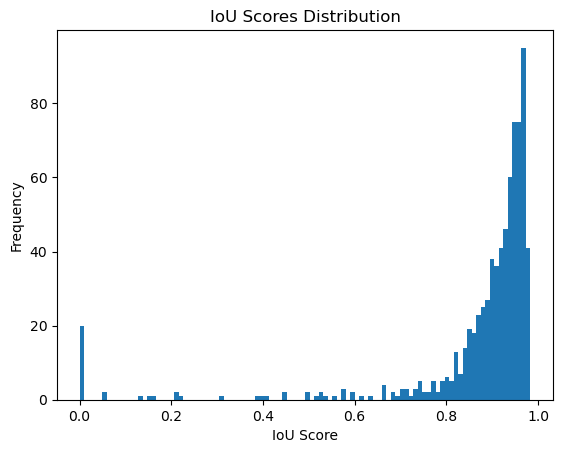

In [5]:
Iou_scores = []
for i in range(preds_unp.shape[0]):
    Iou_scores.append(jaccard_index(preds_unp[i]>0.5, preds_p[i]>0.5))
plt.hist(Iou_scores, bins=100)
plt.title("IoU Scores Distribution")
plt.xlabel("IoU Score")
plt.ylabel("Frequency")
plt.show()

In [11]:
nan_ids = np.where(np.isnan(Iou_scores))[0]
print(f"Number of NaN IoU scores: {len(nan_ids)}")

Number of NaN IoU scores: 0


In [13]:
Iou_scores_array = np.array(Iou_scores)
np.all(np.isclose(Iou_scores_array, 1 - NHD_scores) | (np.isnan(NHD_scores) & (Iou_scores_array == 0)))

True

In [8]:
mask = get_mask(
    preds_unp,
    preds_p,
    0.5,
)
HD_scores = HammingDistanceEval(threshold=0.5)(preds_p, preds_unp, mask)

In [9]:
np.all(np.isclose(HD_scores, NHD_scores) | (np.isnan(NHD_scores) & np.isnan(HD_scores)))

True